# Regression Project
#### Build a linear regression model that predicts the price column in the dataset on San Francisco Apartment rentals.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score as r2, mean_absolute_error as mae, mean_squared_error as mse

rentals_df = pd.read_csv("sf_clean.csv")

rentals_df.head()

,price,sqft,beds,bath,laundry,pets,housing_type,parking,hood_district
0,6800,1600.0,2.0,2.0,(a) in-unit,(d) no pets,(c) multi,(b) protected,7.0
1,3500,550.0,1.0,1.0,(a) in-unit,(a) both,(c) multi,(b) protected,7.0
2,5100,1300.0,2.0,1.0,(a) in-unit,(a) both,(c) multi,(d) no parking,7.0
3,9000,3500.0,3.0,2.5,(a) in-unit,(d) no pets,(c) multi,(b) protected,7.0
4,3100,561.0,1.0,1.0,(c) no laundry,(a) both,(c) multi,(d) no parking,7.0


## Data Dictionary

1. **Price**: The price of the rental and our target variable
2. **sqft**: The area in square feet of the rental
3. **beds**: The number of bedrooms in the rental
4. **bath**: The number of bathrooms in the rental
5. **laundry**: Does the rental have a laundry machine inside the house, a shared laundry machine, or no laundry on site?
6. **pets**: Does the rental allow pets? Cats only, dogs only or both cats and dogs?
7. **Housing type**: Is the rental in a multi-unit building, a building with two units, or a stand-alone house?
8. **Parking**: Does the apartment offer a parking space? No, protected in a garage, off-street in a parking lot, or valet service?
9. **hood district**: Which part of San Francisco is the apartment located?


In [2]:
rentals_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 989 entries, 0 to 988
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          989 non-null    int64  
 1   sqft           989 non-null    float64
 2   beds           989 non-null    float64
 3   bath           989 non-null    float64
 4   laundry        989 non-null    object 
 5   pets           989 non-null    object 
 6   housing_type   989 non-null    object 
 7   parking        989 non-null    object 
 8   hood_district  989 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 69.7+ KB


## EDA
1 - Based on the range of prices below, we may need to subset our data based on some value to predict more "realistic" apartments. Possibly subset based on square-footage.
2 - The 'hood_district' feature was read in as an integer but is really a categorical feature. Let's fix that.

In [3]:
rentals_df["hood_district"] = rentals_df["hood_district"].astype("object")

In [4]:
rentals_df.describe()

,price,sqft,beds,bath
count,989.000000,989.000000,989.000000,989.000000
mean,3595.035389,976.765420,1.679474,1.390293
std,1546.222670,474.629798,1.076710,0.562714
min,750.000000,150.000000,0.000000,1.000000
25%,2650.000000,650.000000,1.000000,1.000000
50%,3300.000000,900.000000,2.000000,1.000000
75%,4242.000000,1200.000000,2.000000,2.000000
max,19000.000000,3500.000000,6.000000,4.000000


There are some very rare, expensive apartments that cost over 10k.

<Axes: xlabel='price', ylabel='Count'>

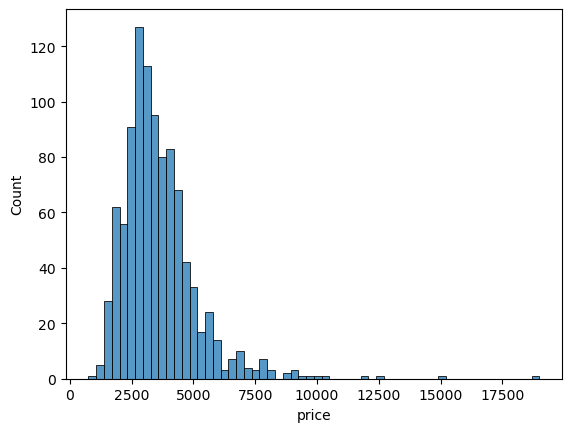

In [7]:
sns.histplot(rentals_df, x="price")

Most of our numeric features are positively correlated with each other, could cause problems.

It's good to see that we have some strong correlations with our target here though.

<Axes: >

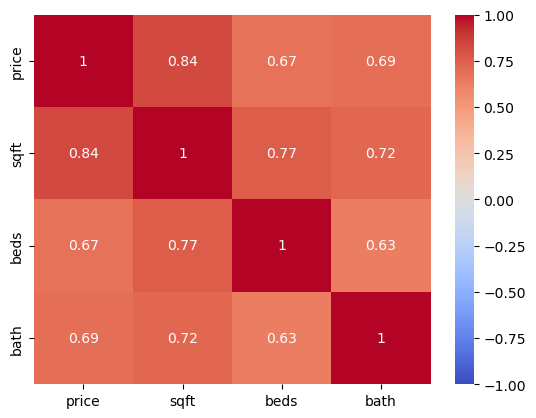

In [8]:
 sns.heatmap(
     rentals_df.corr(numeric_only=True),
     vmin=-1,
     vmax=1,
     cmap="coolwarm",
     annot=True
 )

Based on the pairplot below, we may be able to slice off the most expensive apartments by subsetting to only apartments <2500 sqft.

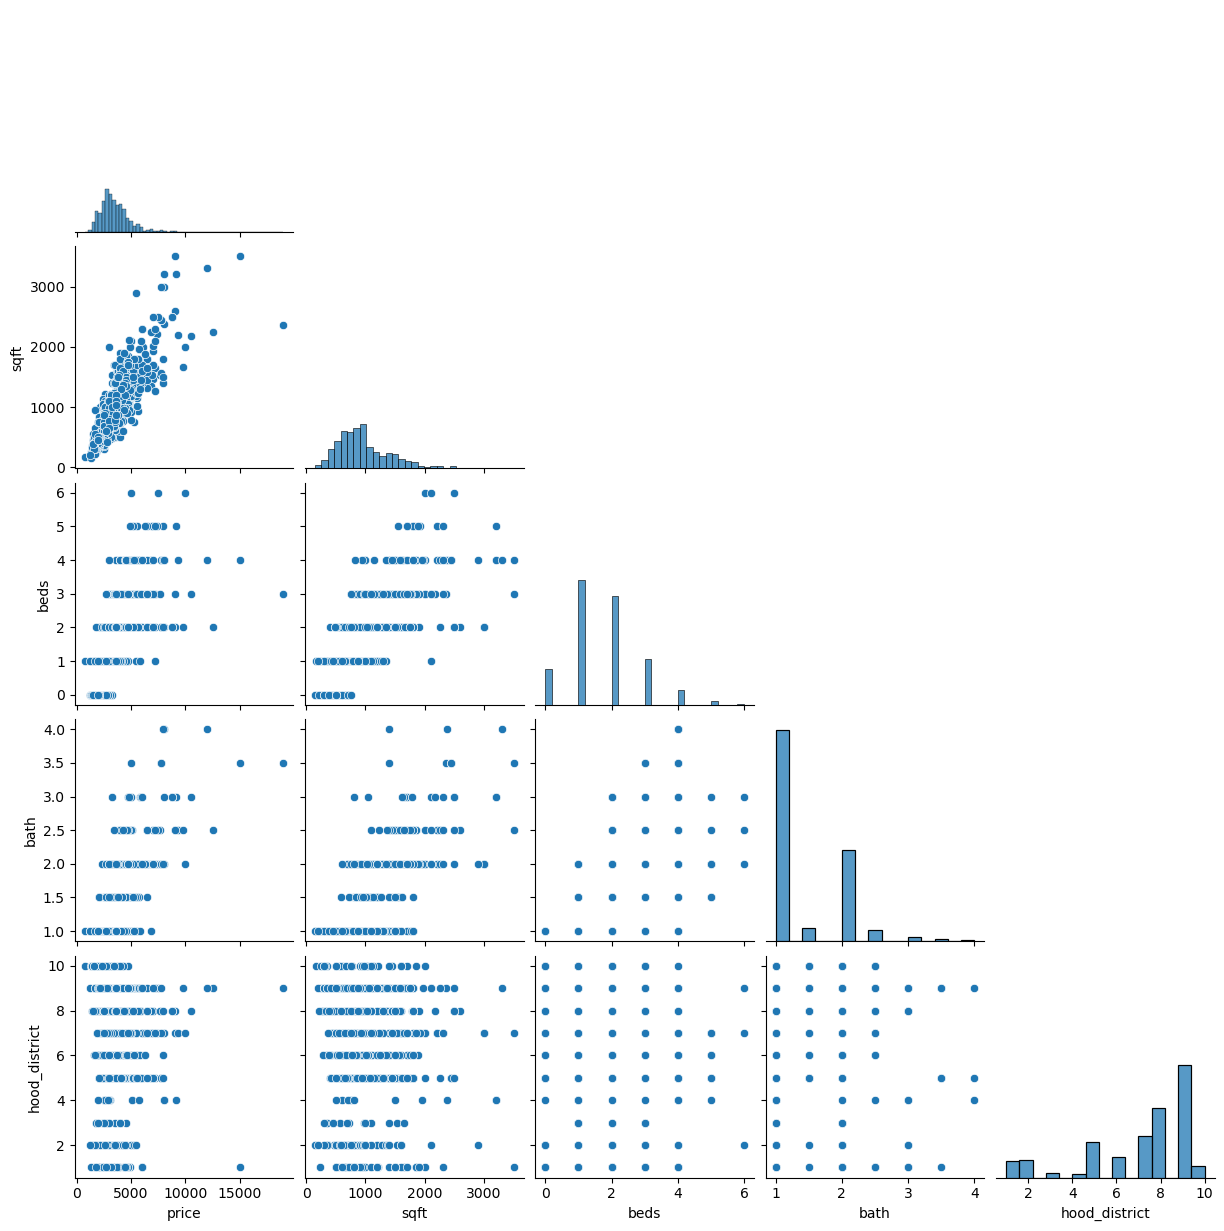

In [9]:
sns.pairplot(rentals_df, corner=True)

Moving on to our categorical features, we have some rare categories that may need to be binned together.

We should consider:

###### 1 - Pets: Bin 'dogs', and 'both' into a 'dogs' 'allows_dogs' category.
###### 2 - Housing_type: Group 'multi' and 'double' together
###### 3 - Parking: Group 'protected', 'off-street', and 'valet' together
###### 4 - We should bin some of our lower count neighborhoods with neighboring ones. Let's look at average pricing for each and see which are related based on price.

In [10]:
# # Let's check the frequency of our categorical features

def value_counter(dataframe):
    value_series = pd.DataFrame()
    for col in dataframe.select_dtypes(['object']).columns:
        print(dataframe[col].value_counts())

value_counter(rentals_df)

laundry
(a) in-unit       488
(b) on-site       370
(c) no laundry    131
Name: count, dtype: int64
pets
(d) no pets    510
(a) both       367
(c) cats        91
(b) dogs        21
Name: count, dtype: int64
housing_type
(c) multi     937
(a) single     40
(b) double     12
Name: count, dtype: int64
parking
(d) no parking    478
(b) protected     439
(c) off-street     38
(a) valet          34
Name: count, dtype: int64
hood_district
9.0     332
8.0     207
7.0     123
5.0     106
6.0      62
2.0      51
1.0      50
10.0     33
3.0      14
4.0      11
Name: count, dtype: int64


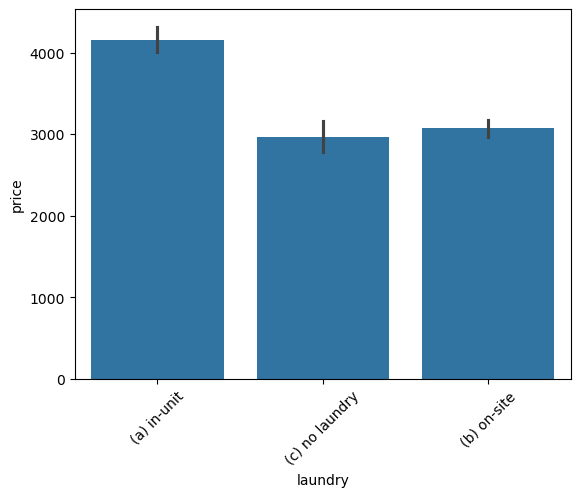

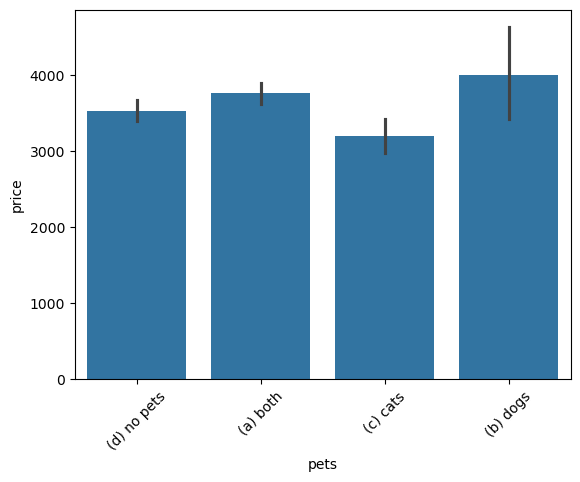

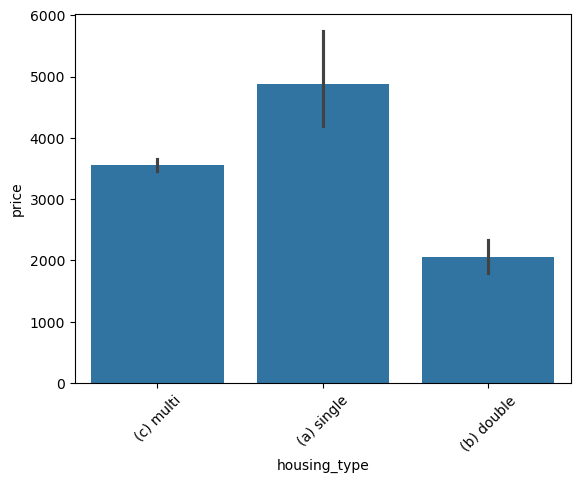

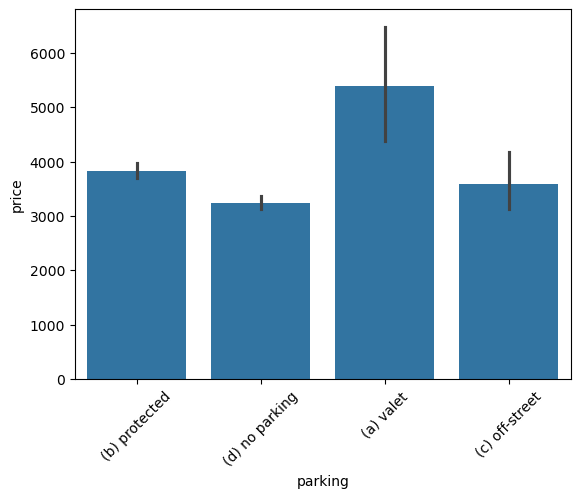

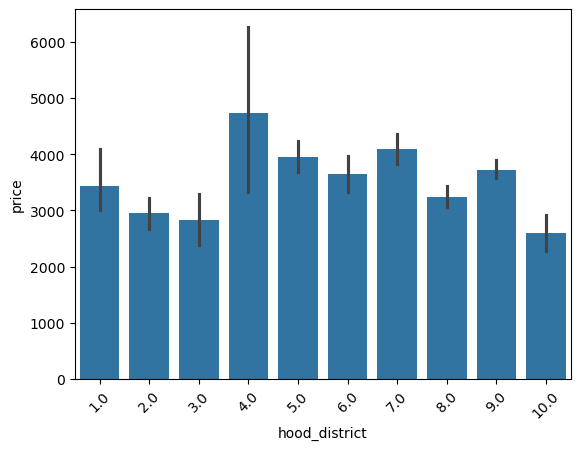

In [11]:
def cat_plotter(data, target):
     for col in data.select_dtypes(['object']).columns:
         sns.barplot(data=data, x=col, y=target)
         plt.xticks(rotation=45)
         plt.show()

cat_plotter(rentals_df, "price")

## Feature Engineering
1 - Group Categories together.

2 - Trying a Squared Term for Bedrooms, sqft, and bath

In [79]:
laundry_map = {
    "(a) in-unit": "in_unit",
    "(b) on-site": "not_in_unit",
    "(c) no laundry": "not_in_unit",
}

pet_map = {
    "(a) both": "allows_dogs",
    "(b) dogs": "allows_dogs",
    "(c) cats": "no_dogs",
    "(d) no pets": "no_dogs"
}

housing_type_map = {
    "(a) single": "single",
    "(b) double": "multi",
    "(c) multi": "multi",
}

district_map = {
    1.0: "west",
    2.0: "southwest",
    3.0: "southwest",
    4.0: "central",
    5.0: "central",
    6.0: "central",
    7.0: "marina",
    8.0: "north beach",
    9.0: "FiDi/SOMA",
    10.0: "southwest"
}

In [107]:
eng_df = rentals_df.assign(
    hood_district = rentals_df["hood_district"].map(district_map),
    housing_type = rentals_df["housing_type"].map(housing_type_map),
    pets = rentals_df["pets"].map(pet_map),
    laundry = rentals_df["laundry"].map(laundry_map),

    # sqft2 = rentals_df["sqft"] ** 2,
    # sqft3 = rentals_df["sqft"] ** 3,
    # beds2 = rentals_df["beds"] ** 2,
    # beds3 = rentals_df["beds"] ** 3,
    # bath2 = rentals_df["bath"] ** 2,
    # bath3 = rentals_df["bath"] ** 3,
    beds_bath_ratio = rentals_df["beds"] / rentals_df["bath"]
)

#eng_df = pd.get_dummies(eng_df, drop_first=True)
eng_df = pd.get_dummies(eng_df, drop_first=True).astype(int)

In [108]:
eng_df.head()

,price,sqft,beds,bath,beds_bath_ratio,laundry_not_in_unit,pets_no_dogs,housing_type_single,parking_(b) protected,parking_(c) off-street,parking_(d) no parking,hood_district_central,hood_district_marina,hood_district_north beach,hood_district_southwest,hood_district_west
0,6800,1600,2,2,1,0,1,0,1,0,0,0,1,0,0,0
1,3500,550,1,1,1,0,0,0,1,0,0,0,1,0,0,0
2,5100,1300,2,1,2,0,0,0,0,0,1,0,1,0,0,0
3,9000,3500,3,2,1,0,1,0,1,0,0,0,1,0,0,0
4,3100,561,1,1,1,1,0,0,0,0,1,0,1,0,0,0


## Data Splitting

In [109]:
from sklearn.model_selection import train_test_split

target = "price"

drop_cols = [
      "pets_no_dogs",
      "housing_type_single",
      # "beds_bath_ratio"
]

X = sm.add_constant(eng_df.drop([target] + drop_cols, axis=1))

# Log transform slightly improves normality
y = np.log(eng_df[target])
# y = eng_df[target]

# Test Split
X, X_test, y, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2023
)

## Model Fitting & Validation Scoring

In [110]:
def cross_val(X, y, n_splits):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=2023)
    # Create a list to store validation scores for each fold

    cv_lm_tr_r2s = []
    cv_lm_tr_mae = []
    cv_lm_val_r2s = []
    cv_lm_val_mae = []

    for train_ind, val_ind in kf.split(X, y):
        # Subset data based on CV folds
        X_train, y_train = X.iloc[train_ind], y.iloc[train_ind]
        X_val, y_val = X.iloc[val_ind], y.iloc[val_ind]

        # Fit the model on fold's training data
        model = sm.OLS(y_train, X_train).fit()

        # Append validation score to list
        cv_lm_tr_r2s.append(r2(y_train, model.predict(X_train)))
        cv_lm_tr_mae.append(mae(y_train, model.predict(X_train)))
        cv_lm_val_r2s.append(r2(y_val, model.predict(X_val)))
        cv_lm_val_mae.append(mae(y_val, model.predict(X_val)))

    print(f"All Training R2s: {[round(x, 3) for x in cv_lm_tr_r2s]}")
    print(f"Training R2s: {round(np.mean(cv_lm_tr_r2s), 3)} +- {round(np.std(cv_lm_tr_r2s), 3)}")

    print(f"Training MAEs: {[round(x, 3) for x in cv_lm_tr_mae]}")
    print(f"Training MAEs: {round(np.mean(cv_lm_tr_mae), 3)} +- {round(np.std(cv_lm_tr_mae), 3)}")

    print(f"All Validation R2s: {[round(x, 3) for x in cv_lm_val_r2s]}")
    print(f"Cross Val R2s: {round(np.mean(cv_lm_val_r2s), 3)} +- {round(np.std(cv_lm_val_r2s), 3)}")

    print(f"All Validation MAEs: {[round(x, 3) for x in cv_lm_val_mae]}")
    print(f"Cross Val MAEs: {round(np.mean(cv_lm_val_mae), 3)} +- {round(np.std(cv_lm_val_mae), 3)}")

    return model

#X = pd.get_dummies(X, drop_first=True)
#X = X.astype(float)
model = cross_val(X, y, 5)

All Training R2s: [0.816, 0.817, 0.806, 0.818, 0.81]
Training R2s: 0.813 +- 0.004
Training MAEs: [0.126, 0.131, 0.13, 0.128, 0.131]
Training MAEs: 0.129 +- 0.002
All Validation R2s: [0.797, 0.79, 0.825, 0.784, 0.812]
Cross Val R2s: 0.802 +- 0.015
All Validation MAEs: [0.144, 0.126, 0.128, 0.136, 0.126]
Cross Val MAEs: 0.132 +- 0.007


In [111]:
# Model p-values: a few features have > .05
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.810
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     203.6
Date:                Tue, 14 Apr 2026   Prob (F-statistic):          1.54e-213
Time:                        22:09:43   Log-Likelihood:                 225.56
No. Observations:                 633   AIC:                            -423.1
Df Residuals:                     619   BIC:                            -360.8
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         7.6710      0.051    149.639      0.000       7.570       7.772
sqft                          0.0004   2.55e-05     15.970      0.000       0.000       0.000
beds                          0.0304      0.018      1.678      0.094      -0.005       0.066
bath                          0.1294      0.025      5.108      0.000       0.080       0.179
beds_bath_ratio               0.0872      0.019      4.523      0.000       0.049       0.125
laundry_not_in_unit          -0.0968      0.016     -6.055      0.000      -0.128      -0.065
parking_(b) protected        -0.1980      0.038     -5.175      0.000      -0.273      -0.123
parking_(c) off-street       -0.1623      0.054     -3.006      0.003      -0.268      -0.056
parking_(d) no parking       -0.2690      0.040     -6.810      0.000      -0.347      -0.191
hood_district_central         0.0274      0.021      1.313      0.190      -0.014       0.068
hood_district_marina          0.0837      0.024      3.461      0.001       0.036       0.131
hood_district_north beach    -0.0220      0.020     -1.080      0.280      -0.062       0.018
hood_district_southwest      -0.1677      0.026     -6.436      0.000      -0.219      -0.116
hood_district_west           -0.0350      0.033     -1.071      0.285      -0.099       0.029
==============================================================================
Omnibus:                       26.901   Durbin-Watson:                   1.907
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               59.194
Skew:                           0.209   Prob(JB):                     1.40e-13
Kurtosis:                       4.439   Cond. No.                     1.33e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.33e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Assumptions Checking

Linearity → no obvious curvature

Independence → DW Test Statistic looks good

Normality → slightly off before log transform, much better afterwards

No Perfect Multicollinearity → VIFs look OK

Equal Variance → slight heteroskedasticity prior to log transform

In [112]:
def residual_analysis_plots(model):
    import scipy.stats as stats
    import matplotlib.pyplot as plt

    predictions = model.predict()
    residuals = model.resid

    fig, ax = plt.subplots(1, 2, sharey="all", figsize=(10, 6))

    sns.scatterplot(x=predictions, y=residuals, ax=ax[0])
    ax[0].set_title("Residual Plot")
    ax[0].set_xlabel("Predictions")
    ax[0].set_ylabel("Residuals")

    stats.probplot(residuals, dist="norm", plot=ax[1])
    ax[1].set_title("Normal Q-Q Plot")

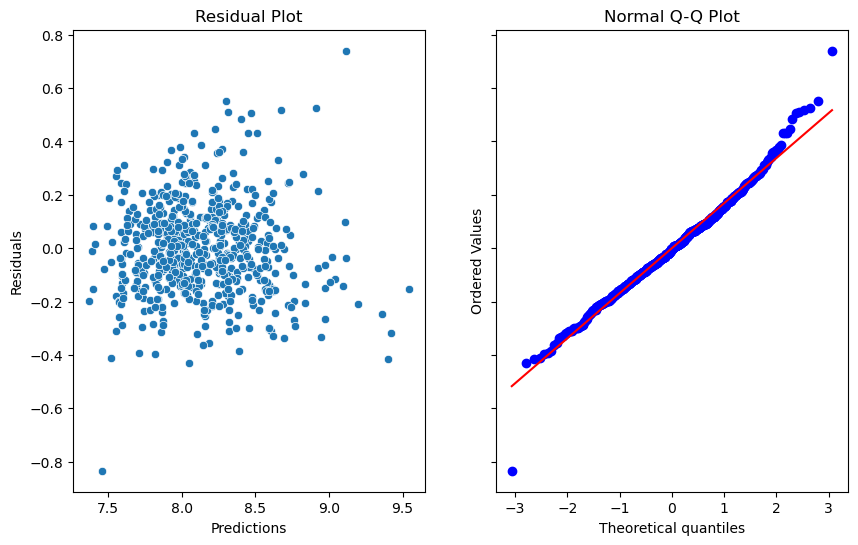

In [113]:
residual_analysis_plots(model)

In [114]:
# VIF looks OK -- our parking dummy features are a bit high but no major concern

from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

pd.Series(
    [vif(X.values, i) for i in range(X.shape[1])],
    index=X.columns
)

const                        56.273742
sqft                          3.406615
beds                          8.941364
bath                          4.187793
beds_bath_ratio               4.472665
laundry_not_in_unit           1.379717
parking_(b) protected         7.651451
parking_(c) off-street        2.224741
parking_(d) no parking        8.304146
hood_district_central         1.381153
hood_district_marina          1.381158
hood_district_north beach     1.434324
hood_district_southwest       1.317085
hood_district_west            1.210074
dtype: float64

In [115]:
influence = model.get_influence()
inf_summary_df = influence.summary_frame()

inf_summary_df["cooks_d"].sort_values(ascending=False).head()

253    0.088106
602    0.047525
56     0.038404
863    0.037121
3      0.026667
Name: cooks_d, dtype: float64

In [116]:
X.loc[253]

const                           1.0
sqft                         2358.0
beds                            3.0
bath                            3.0
beds_bath_ratio                 0.0
laundry_not_in_unit             0.0
parking_(b) protected           0.0
parking_(c) off-street          0.0
parking_(d) no parking          0.0
hood_district_central           0.0
hood_district_marina            0.0
hood_district_north beach       0.0
hood_district_southwest         0.0
hood_district_west              0.0
Name: 253, dtype: float64

In [117]:
np.exp(y.loc[253])

18999.999999999993

## Final Model Fit

In [118]:
final_model = sm.OLS(y, X).fit()

final_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     259.4
Date:                Tue, 14 Apr 2026   Prob (F-statistic):          4.81e-272
Time:                        22:09:55   Log-Likelihood:                 294.09
No. Observations:                 791   AIC:                            -560.2
Df Residuals:                     777   BIC:                            -494.7
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         7.6491      0.045    170.361      0.000       7.561       7.737
sqft                          0.0004   2.32e-05     17.820      0.000       0.000       0.000
beds                          0.0352      0.016      2.148      0.032       0.003       0.067
bath                          0.1259      0.023      5.503      0.000       0.081       0.171
beds_bath_ratio               0.0828      0.018      4.726      0.000       0.048       0.117
laundry_not_in_unit          -0.0944      0.014     -6.711      0.000      -0.122      -0.067
parking_(b) protected        -0.1772      0.033     -5.306      0.000      -0.243      -0.112
parking_(c) off-street       -0.1794      0.045     -3.958      0.000      -0.268      -0.090
parking_(d) no parking       -0.2498      0.035     -7.240      0.000      -0.318      -0.182
hood_district_central         0.0329      0.019      1.768      0.077      -0.004       0.069
hood_district_marina          0.0866      0.021      4.092      0.000       0.045       0.128
hood_district_north beach    -0.0259      0.018     -1.454      0.146      -0.061       0.009
hood_district_southwest      -0.1916      0.023     -8.412      0.000      -0.236      -0.147
hood_district_west           -0.0503      0.029     -1.714      0.087      -0.108       0.007
==============================================================================
Omnibus:                       25.768   Durbin-Watson:                   1.870
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               48.445
Skew:                           0.204   Prob(JB):                     3.02e-11
Kurtosis:                       4.142   Cond. No.                     1.28e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.28e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [120]:
print(mae(np.exp(y_test), np.exp(final_model.predict(X_test))))
# print(f"Test MAE: {mae(y_test, model.predict(X_test))}") #468.13 if not transformed

print(f"Test R2: {r2(y_test, final_model.predict(X_test))}")

435.2210348531887
Test R2: 0.7947593864817104
